# Particle Identification

In [56]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
import os
import joblib
import seaborn as sns
import numpy as np

In [57]:
sns.set(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [58]:
SEED=42

In [59]:
df = pd.read_csv("./data/training.csv")

In [60]:
df.columns.shape[0]

50

ID - id value for tracks (presents only in the test file for the submitting purposes) \
Label - string valued observable denoting particle types. Can take values "Electron", "Muon", "Kaon", "Proton", "Pion" and "Ghost". This column is absent in the test file. \
FlagSpd - flag (0 or 1), if reconstructed track passes through Spd \
FlagPrs - flag (0 or 1), if reconstructed track passes through Prs \
FlagBrem - flag (0 or 1), if reconstructed track passes through Brem \
FlagEcal - flag (0 or 1), if reconstructed track passes through Ecal \
FlagHcal - flag (0 or 1), if reconstructed track passes through Hcal \
FlagRICH1 - flag (0 or 1), if reconstructed track passes through the first RICH detector \
FlagRICH2 - flag (0 or 1), if reconstructed track passes through the second RICH detector \
FlagMuon - flag (0 or 1), if reconstructed track passes through muon stations (Muon) \
SpdE - energy deposit associated to the track in the Spd \
PrsE - energy deposit associated to the track in the Prs \
EcalE - energy deposit associated to the track in the Hcal \
HcalE - energy deposit associated to the track in the Hcal \
PrsDLLbeElectron - delta log-likelihood for a particle candidate to be electron using information from Prs \
BremDLLbeElectron - delta log-likelihood for a particle candidate to be electron using information from Brem \
TrackP - particle momentum \
TrackPt - particle transverse momentum \
TrackNDoFSubdetector1 - number of degrees of freedom for track fit using hits in the tracking sub-detector1 \
TrackQualitySubdetector1 - chi2 quality of the track fit using hits in the tracking sub-detector1 \
TrackNDoFSubdetector2 - number of degrees of freedom for track fit using hits in the tracking sub-detector2 \
TrackQualitySubdetector2 - chi2 quality of the track fit using hits in the tracking sub-detector2 \
TrackNDoF - number of degrees of freedom for track fit using hits in all tracking sub-detectors \
TrackQualityPerNDoF - chi2 quality of the track fit per degree of freedom \
TrackDistanceToZ - distance between track and z-axis (beam axis) \
Calo2dFitQuality - quality of the 2d fit of the clusters in the calorimeter \
Calo3dFitQuality - quality of the 3d fit in the calorimeter with assumption that particle was electron \
EcalDLLbeElectron - delta log-likelihood for a particle candidate to be electron using information from Ecal \
EcalDLLbeMuon - delta log-likelihood for a particle candidate to be muon using information from Ecal \
EcalShowerLongitudinalParameter - longitudinal parameter of Ecal shower \
HcalDLLbeElectron - delta log-likelihood for a particle candidate to be electron using information from Hcal \
HcalDLLbeMuon - delta log-likelihood for a particle candidate to be using information from Hcal \
RICHpFlagElectron - flag (0 or 1) if momentum is greater than threshold for electrons to produce Cherenkov light \
RICHpFlagProton - flag (0 or 1) if momentum is greater than threshold for protons to produce Cherenkov light \
RICHpFlagPion - flag (0 or 1) if momentum is greater than threshold for pions to produce Cherenkov light \
RICHpFlagKaon - flag (0 or 1) if momentum is greater than threshold for kaons to produce Cherenkov light \
RICHpFlagMuon - flag (0 or 1) if momentum is greater than threshold for muons to produce Cherenkov light \
RICH_DLLbeBCK - delta log-likelihood for a particle candidate to be background using information from RICH \
RICH_DLLbeKaon - delta log-likelihood for a particle candidate to be kaon using information from RICH \
RICH_DLLbeElectron - delta log-likelihood for a particle candidate to be electron using information from RICH \
RICH_DLLbeMuon - delta log-likelihood for a particle candidate to be muon using information from RICH \
RICH_DLLbeProton - delta log-likelihood for a particle candidate to be proton using information from RICH \
MuonFlag - muon flag (is this track muon) which is determined from muon stations \
MuonLooseFlag muon flag (is this track muon) which is determined from muon stations using looser criteria \
MuonLLbeBCK - log-likelihood for a particle candidate to be not muon using information from muon stations \
MuonLLbeMuon - log-likelihood for a particle candidate to be muon using information from muon stations \
DLLelectron - delta log-likelihood for a particle candidate to be electron using information from all subdetectors \
DLLmuon - delta log-likelihood for a particle candidate to be muon using information from all subdetectors \
DLLkaon - delta log-likelihood for a particle candidate to be kaon using information from all subdetectors \
DLLproton - delta log-likelihood for a particle candidate to be proton using information from all subdetectors \
GhostProbability - probability for a particle candidate to be ghost track. This variable is an output of classification model used in the tracking algorithm. \
Spd stands for Scintillating Pad Detector, Prs - Preshower, Ecal - electromagnetic calorimeter, Hcal - hadronic calorimeter, Brem denotes traces of the particles that were deflected by detector.

In [61]:
CAT_FEATURES = [col for col in df.drop(columns=['Label']).columns if len(np.unique(df[col])) <= 10]

In [62]:
df.isna().sum() # на первый взгляд чистый

TrackP                             0
TrackNDoFSubdetector2              0
BremDLLbeElectron                  0
MuonLooseFlag                      0
FlagSpd                            0
SpdE                               0
EcalDLLbeElectron                  0
DLLmuon                            0
RICHpFlagElectron                  0
EcalDLLbeMuon                      0
TrackQualitySubdetector2           0
FlagPrs                            0
DLLelectron                        0
DLLkaon                            0
EcalE                              0
TrackQualityPerNDoF                0
DLLproton                          0
PrsDLLbeElectron                   0
FlagRICH1                          0
MuonLLbeBCK                        0
FlagHcal                           0
EcalShowerLongitudinalParameter    0
Calo2dFitQuality                   0
TrackPt                            0
TrackDistanceToZ                   0
RICHpFlagPion                      0
HcalDLLbeElectron                  0
C

In [63]:
df

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
0,74791.156263,15.0,0.232275,1.0,1.0,3.2,-2.505719,6.604153,1.0,1.929960,...,28.0,1.0,-7.213300,-0.280200,5586.589846,1.0,1.0,10.422315,-2.081143e-07,-24.824400
1,2738.489989,15.0,-0.357748,0.0,1.0,3.2,1.864351,0.263651,1.0,-2.061959,...,32.0,1.0,-0.324317,1.707283,-0.000007,0.0,1.0,43.334935,2.771583e+00,-0.648017
2,2161.409908,17.0,-999.000000,0.0,0.0,-999.0,-999.000000,-999.000000,0.0,-999.000000,...,27.0,0.0,-999.000000,-999.000000,-999.000000,0.0,0.0,-999.000000,-9.990000e+02,-999.000000
3,15277.730490,20.0,-0.638984,0.0,1.0,3.2,-2.533918,-8.724949,1.0,-3.253981,...,36.0,1.0,-35.202221,-14.742319,4482.803707,0.0,1.0,2.194175,-3.070819e+00,-29.291519
4,7563.700195,19.0,-0.638962,0.0,1.0,3.2,-2.087146,-7.060422,1.0,-0.995816,...,33.0,1.0,25.084287,-10.272412,5107.554680,0.0,1.0,0.000015,-5.373712e+00,23.653087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,3539.219954,20.0,-0.461405,0.0,1.0,3.2,-2.538767,-9.160428,1.0,-2.327719,...,37.0,1.0,-0.000024,-23.086524,-999.000000,0.0,0.0,4.114066,-1.524512e+01,-0.110724
1199996,6251.180189,18.0,-999.000000,0.0,1.0,3.2,2.149471,-2.966569,0.0,-2.708717,...,23.0,0.0,-999.000000,-999.000000,3250.704077,0.0,1.0,40.043675,-9.990000e+02,-999.000000
1199997,18593.580083,7.0,-999.000000,0.0,0.0,-999.0,-999.000000,0.126841,1.0,-999.000000,...,22.0,1.0,-4.089321,1.325879,-999.000000,0.0,0.0,-999.000000,3.085794e-01,-1.585221
1199998,4903.330078,18.0,-0.553603,1.0,1.0,3.2,-1.200371,8.458183,1.0,0.501782,...,33.0,1.0,-0.000005,-13.001305,9093.200179,1.0,1.0,2.742730,2.747800e+01,-0.482605


In [64]:
num_nulls_counts = []
for na in df.columns:
    na_sum = np.sum(df[na] == -999)
    print(na, na_sum)
    if na not in CAT_FEATURES:
        num_nulls_counts.append(na)

TrackP 0
TrackNDoFSubdetector2 0
BremDLLbeElectron 249561
MuonLooseFlag 0
FlagSpd 0
SpdE 176167
EcalDLLbeElectron 218857
DLLmuon 13391
RICHpFlagElectron 0
EcalDLLbeMuon 218857
TrackQualitySubdetector2 0
FlagPrs 0
DLLelectron 13391
DLLkaon 13391
EcalE 218857
TrackQualityPerNDoF 0
DLLproton 13391
PrsDLLbeElectron 178495
FlagRICH1 0
MuonLLbeBCK 971253
FlagHcal 0
EcalShowerLongitudinalParameter 359193
Calo2dFitQuality 219473
TrackPt 0
TrackDistanceToZ 0
RICHpFlagPion 0
HcalDLLbeElectron 281986
Calo3dFitQuality 359193
FlagEcal 0
MuonLLbeMuon 971253
TrackNDoFSubdetector1 0
RICHpFlagProton 0
RICHpFlagKaon 0
GhostProbability 0
TrackQualitySubdetector1 0
Label 0
RICH_DLLbeBCK 58238
FlagRICH2 0
FlagBrem 0
HcalDLLbeMuon 281986
TrackNDoF 0
RICHpFlagMuon 0
RICH_DLLbeKaon 58238
RICH_DLLbeElectron 58238
HcalE 281986
MuonFlag 0
FlagMuon 0
PrsE 178495
RICH_DLLbeMuon 58238
RICH_DLLbeProton 58238


# Оценка датасета

<Axes: >

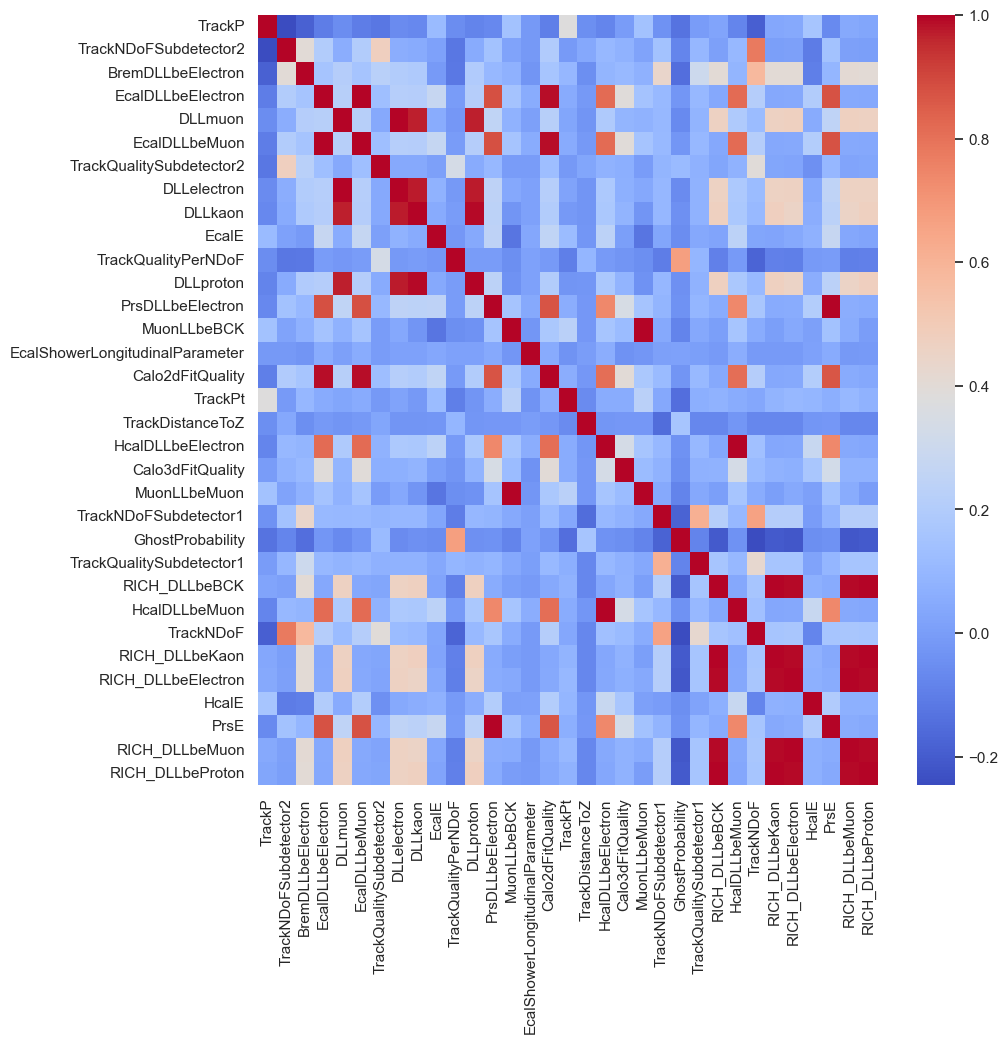

In [65]:
sns.heatmap(df.drop(columns=['Label'] + list(i for i in CAT_FEATURES)).corr(), cmap='coolwarm')

In [66]:
df_clean = df[~(df[num_nulls_counts] == -999.0).any(axis=1)].reset_index(drop=True)

In [67]:
df_clean

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
0,100204.546879,14.0,0.014732,1.0,1.0,3.2,-1.861633,4.397592,1.0,0.000005,...,35.0,1.0,-1.429587,-0.012587,3727.108158,1.0,0.0,1.919897,0.000013,-17.489586
1,103367.742185,16.0,-0.417101,1.0,1.0,3.2,-2.482124,7.205888,1.0,1.262222,...,29.0,1.0,-5.573694,-0.789194,1185.187866,1.0,1.0,2.194178,-0.926094,-20.683094
2,29690.279292,18.0,-0.237696,1.0,0.0,3.2,-2.665202,5.141363,1.0,0.501779,...,32.0,1.0,0.921087,-0.097913,2652.422595,1.0,1.0,8.502420,-0.508913,-3.320313
3,13947.299796,14.0,-0.046242,1.0,1.0,3.2,-1.203815,-3.699127,1.0,-2.197351,...,30.0,1.0,19.657800,-3.664800,1379.425923,0.0,1.0,3.291265,-2.663600,42.613201
4,7212.589861,14.0,0.269433,1.0,1.0,0.0,-1.715660,-3.827066,1.0,0.494717,...,28.0,1.0,-32.328089,-32.168589,2252.754145,1.0,1.0,2.468430,-11.893891,-35.983092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125424,83506.890623,18.0,-0.554164,1.0,1.0,3.2,-2.344259,-0.438729,1.0,-2.766867,...,42.0,1.0,-4.502202,-0.058102,8708.629896,1.0,1.0,100.383458,0.000998,-21.039702
125425,10011.269531,16.0,-0.638980,1.0,1.0,3.2,-1.644077,3.021498,1.0,0.008404,...,33.0,1.0,-35.924783,-9.668082,2589.232421,1.0,1.0,5.211167,-0.142782,-31.280682
125426,4349.810064,15.0,0.217883,1.0,1.0,0.0,-2.551349,-8.451985,1.0,0.494727,...,33.0,1.0,21.829909,-7.322492,-0.000007,1.0,1.0,0.000002,-7.215292,18.137408
125427,13230.009755,17.0,2.787175,1.0,1.0,3.2,-3.283643,12.366392,1.0,1.794310,...,31.0,1.0,-151.199904,3.742702,1687.839244,1.0,1.0,6.856803,6.822802,-98.466696


<Axes: >

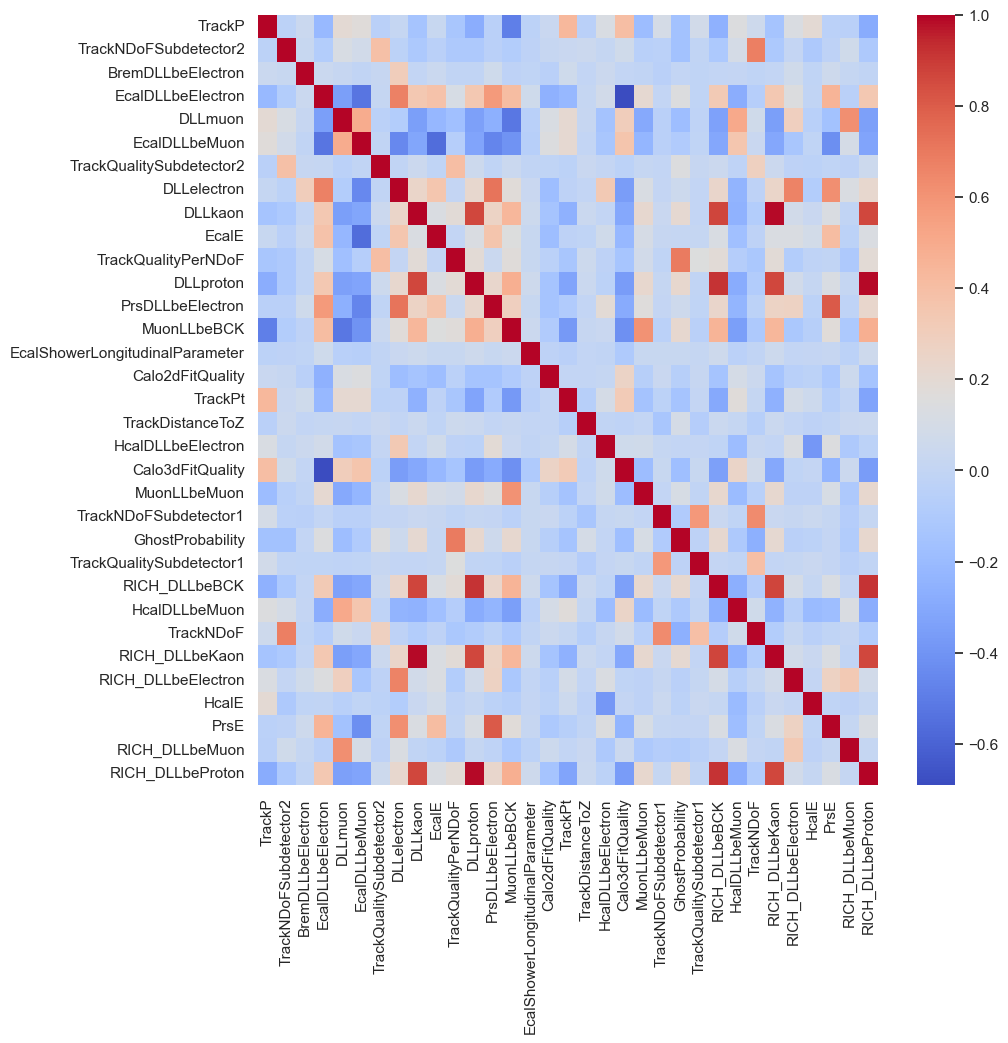

In [68]:
sns.heatmap(df_clean.drop(columns=['Label'] + list(i for i in CAT_FEATURES)).corr(), cmap='coolwarm')

In [69]:
drop_columns = ['DLLkaon', 'DLLproton']
df_clean = df_clean.drop(columns=drop_columns)
df = df.drop(columns=drop_columns)

<Axes: >

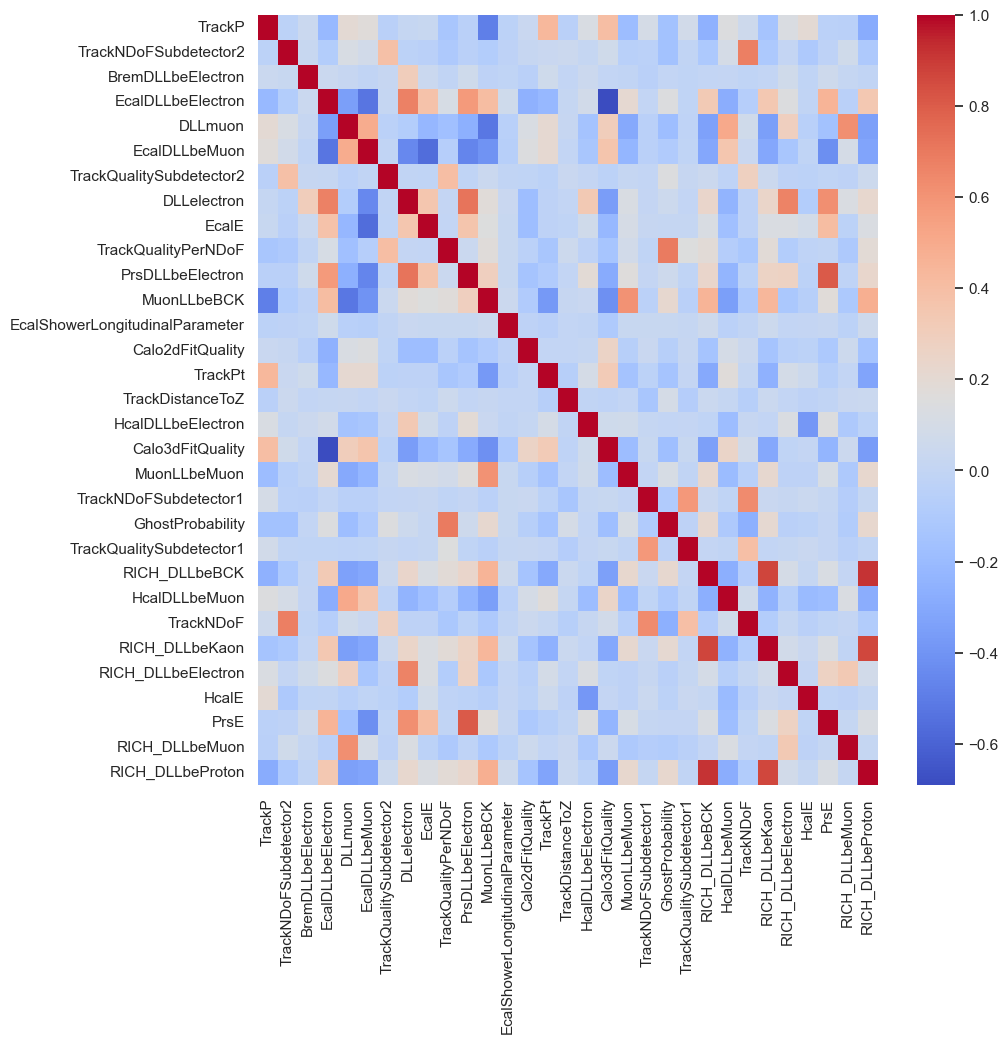

In [70]:
sns.heatmap(df_clean.drop(columns=['Label'] + list(i for i in CAT_FEATURES)).corr(), cmap='coolwarm')

# Новые фичи

In [71]:
df['sin_teth'] = df['TrackPt'] / (df['TrackP'] + 0.000001)

df['log_TrackP'] = np.log1p(df['TrackP'].clip(lower=0))

df['log_TrackPt'] = np.log1p(df['TrackPt'].clip(lower=0))

df['TotalcalE'] = df['EcalE'] + df['HcalE'] + df['PrsE'] + df['SpdE']

# Создание терировочной, валидационной и тестовой выборок

In [72]:
train_test, too_many_rows_so_delete = train_test_split(
    df, test_size=0.95, stratify=df['Label'], random_state=SEED
)

train, test = train_test_split(
    train_test, test_size=0.2, stratify=train_test['Label'], random_state=SEED
)

In [73]:
encoder = LabelEncoder()
X_train, y_train = train.drop(columns=['Label']), encoder.fit_transform(train['Label'])
X_test, y_test = test.drop(columns=['Label']), encoder.transform(test['Label'])

In [74]:
X_train.shape[0]

48000

# Функция обучения моделей

In [100]:
def train_model(
        model_cls,
        params_func,
        X_train = None,
        y_train = None,
        random_state: int = 42,
        n_trials: int = 10,
        cv_folds: int = 5,
        scoring: str = 'roc_auc_ovr'
        ):
    
    def optim(trial):
        params = params_func(trial)

        if 'random_state' in model_cls().get_params():
            params['random_state'] = random_state

        model = model_cls(**params)

        scores = cross_val_score(model, X=X_train, y=y_train, cv=cv_folds, scoring=scoring)

        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(optim, n_trials=n_trials)

    best_params = study.best_params

    if 'random_state' in model_cls().get_params():
        best_params['random_state'] = random_state
    
    final_model = model_cls(**best_params)

    final_model.fit(X_train, y_train)
    return final_model

# Рисуем графики

In [225]:
from sklearn.metrics import confusion_matrix

def plot_cm(
        model, 
        X_test: np.ndarray, 
        y_test: np.ndarray, 
        title: str | None = None, 
        keras=False
    ):
    if keras:
        y_pred = model.predict(X_test).argmax(axis=1)
    else:
        y_pred = model.predict(X_test)

    fig, ax = plt.subplots(figsize=(10, 10))
    
    cm = confusion_matrix(y_true=y_test, y_pred=y_pred, normalize='true')

    sns.heatmap(
        cm, 
        annot=True, 
        ax=ax,
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_,
        cmap='Blues'
    )
    
    ax.set_xlabel('Pred')
    ax.set_ylabel('True')
    ax.set_title(title)

# One rule

In [76]:
from mlxtend.classifier import OneRClassifier
from sklearn.preprocessing import KBinsDiscretizer

In [77]:
bins = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile', subsample=None)

X_train_oner = pd.DataFrame(
    bins.fit_transform(X_train).astype(int),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_oner = pd.DataFrame(
    bins.transform(X_test).astype(int),
    columns=X_test.columns,
    index=X_test.index,
)

feat_count = len(X_train.columns)

remain = list(X_train_oner.columns)

for i in range(feat_count):

    onerule_model = OneRClassifier()
    onerule_model.fit(X_train_oner[remain].values, y_train)

    if i == 0:
        chosen_feat = remain[onerule_model.feature_idx_]
        onerule_f1 = f1_score(y_test, onerule_model.predict(X_test_oner[remain].values), average='macro')
        
        PATH_oner = "models_main/onerule.joblib"
        if not os.path.exists(PATH_oner):
            joblib.dump(onerule_model, PATH_oner)

    chosen_feat = remain[onerule_model.feature_idx_]
    test_f1_score = f1_score(y_test, onerule_model.predict(X_test_oner[remain].values), average='macro')

    print(chosen_feat)
    print("F1 score: ", test_f1_score)
    print('-' * 100)

    remain.remove(chosen_feat)

c:\Users\Luti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Luti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\Luti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\Luti\AppData\Local\Progra

DLLelectron
F1 score:  0.2935399961030701
----------------------------------------------------------------------------------------------------
DLLmuon
F1 score:  0.28565290594410475
----------------------------------------------------------------------------------------------------
RICH_DLLbeElectron
F1 score:  0.2748622853261062
----------------------------------------------------------------------------------------------------
RICH_DLLbeProton
F1 score:  0.3125981967164285
----------------------------------------------------------------------------------------------------
RICH_DLLbeKaon
F1 score:  0.3146998554544368
----------------------------------------------------------------------------------------------------
RICH_DLLbeBCK
F1 score:  0.3051977872798325
----------------------------------------------------------------------------------------------------
TrackPt
F1 score:  0.25978546287652887
-----------------------------------------------------------------------------------------

# Логистическая регрессия

In [78]:
from sklearn.linear_model import LogisticRegression

In [187]:
X_train_log = X_train.replace(-999, None)
X_test_log = X_test.replace(-999, None)

In [188]:
columns = [col for col in X_train_log.columns if X_train_log[col].dtype == 'object']
X_train_log[columns] = X_train_log[columns].astype('float')

In [189]:
X_train_log = X_train_log.fillna(X_train_log.median())
X_test_log = X_test_log.fillna(X_test_log.median())

In [190]:
scaler = StandardScaler()
X_train_log = scaler.fit_transform(X_train_log)
X_test_log = scaler.transform(X_test_log)

In [83]:
def logistic_params(trial):
    return {
        'C': trial.suggest_float('C', 1e-3, 1e1, log=True),
        'solver': 'lbfgs',
        'max_iter': 2000
    }

In [84]:
logistic_model = train_model(LogisticRegression, logistic_params, X_train=X_train_log, y_train=y_train, n_trials=10, cv_folds=5)

[I 2026-05-30 07:02:59,815] A new study created in memory with name: no-name-8fd1177b-9955-449a-8d23-93861b3cf7cc
[I 2026-05-30 07:03:02,796] Trial 0 finished with value: 0.9430637838541667 and parameters: {'C': 0.007234566604576259}. Best is trial 0 with value: 0.9430637838541667.
[I 2026-05-30 07:03:04,673] Trial 1 finished with value: 0.93879775 and parameters: {'C': 0.00120115806900877}. Best is trial 0 with value: 0.9430637838541667.
[I 2026-05-30 07:03:06,811] Trial 2 finished with value: 0.9403365078125001 and parameters: {'C': 0.001836805887180929}. Best is trial 0 with value: 0.9430637838541667.
[I 2026-05-30 07:03:14,499] Trial 3 finished with value: 0.9442843671875 and parameters: {'C': 0.21559187713615827}. Best is trial 3 with value: 0.9442843671875.
[I 2026-05-30 07:03:20,926] Trial 4 finished with value: 0.9441186874999999 and parameters: {'C': 0.09342945641439653}. Best is trial 3 with value: 0.9442843671875.
[I 2026-05-30 07:03:35,025] Trial 5 finished with value: 0.94

In [85]:
y_pred = logistic_model.predict(X_test_log)
logistic_f1 = f1_score(y_test, y_pred, average='macro')

print(logistic_f1)

0.7322799725125999


In [86]:
PATH_logistic = "models_main/logistic.joblib"
if not os.path.exists(PATH_logistic):
    joblib.dump(logistic_model, PATH_logistic)

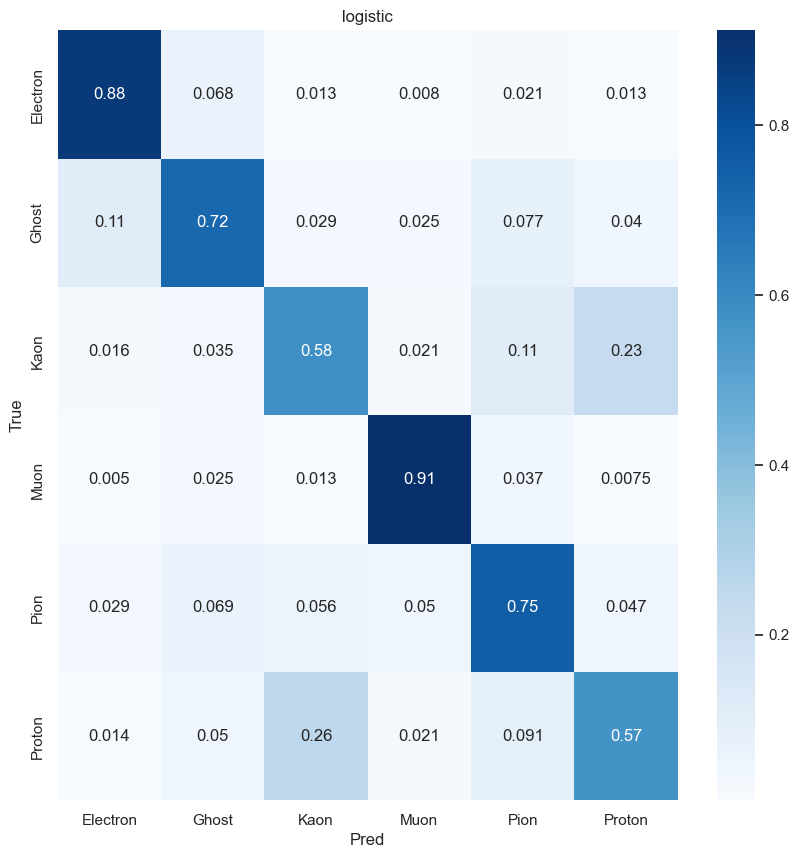

In [203]:
plot_cm(logistic_model, X_test_log, y_test, 'logistic')

In [204]:
X_train_log = X_train.replace(-999, None)
X_test_log = X_test.replace(-999, None)

In [205]:
columns = [col for col in X_train_log.columns if X_train_log[col].dtype == 'object']
X_train_log[columns] = X_train_log[columns].astype('float')

In [206]:
cols_nan = X_train_log.columns[X_train_log.isna().any()].tolist()

In [207]:
for col in cols_nan:
    X_train_log[f'{col}_missing'] = X_train_log[col].isna().astype(int)
    X_test_log[f'{col}_missing'] = X_test_log[col].isna().astype(int)

In [208]:
X_train_log = X_train_log.fillna(X_train_log.median())
X_test_log = X_test_log.fillna(X_test_log.median())

In [209]:
scaler = StandardScaler()
X_train_log = scaler.fit_transform(X_train_log)
X_test_log = scaler.transform(X_test_log)

In [93]:
logistic_model_nan = train_model(LogisticRegression, logistic_params, X_train=X_train_log, y_train=y_train)

[I 2026-05-30 07:03:53,111] A new study created in memory with name: no-name-c37a8944-a6f4-4b5d-aff9-93caf8c13117
[I 2026-05-30 07:04:20,151] Trial 0 finished with value: 0.9455492473958333 and parameters: {'C': 0.38650111448879876}. Best is trial 0 with value: 0.9455492473958333.
[I 2026-05-30 07:04:25,042] Trial 1 finished with value: 0.9428917916666665 and parameters: {'C': 0.0030509476593017547}. Best is trial 0 with value: 0.9455492473958333.
[I 2026-05-30 07:04:40,461] Trial 2 finished with value: 0.9455459322916667 and parameters: {'C': 0.7505338552764909}. Best is trial 0 with value: 0.9455492473958333.
[I 2026-05-30 07:04:45,606] Trial 3 finished with value: 0.9432820104166668 and parameters: {'C': 0.0035985353482592044}. Best is trial 0 with value: 0.9455492473958333.
[I 2026-05-30 07:04:51,467] Trial 4 finished with value: 0.9445087317708334 and parameters: {'C': 0.0074610517992944984}. Best is trial 0 with value: 0.9455492473958333.
[I 2026-05-30 07:04:55,297] Trial 5 finis

In [94]:
y_pred = logistic_model_nan.predict(X_test_log)
logistic_f1_nan = f1_score(y_test, y_pred, average='macro')

print(logistic_f1_nan)

0.7363210641512884


In [95]:
PATH_logistic_nan = "models_main/logistic_nan.joblib"
if not os.path.exists(PATH_logistic_nan):
    joblib.dump(logistic_model_nan, PATH_logistic_nan)

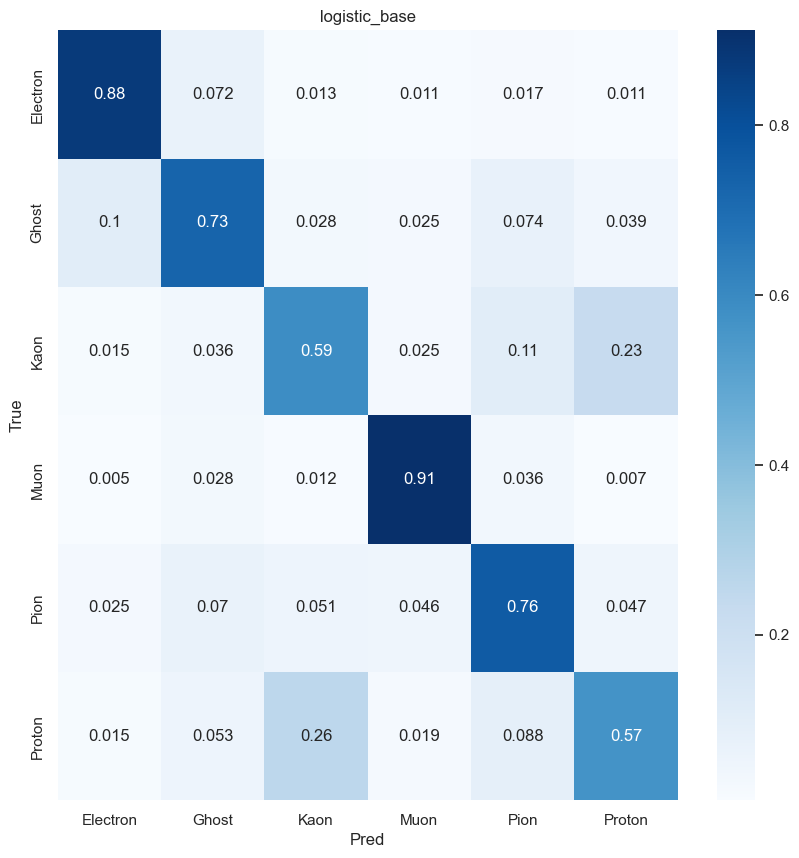

In [215]:
plot_cm(logistic_model_nan, X_test_log, y_test, 'logistic_base')

# k ближайших соседей

In [96]:
from sklearn.neighbors import KNeighborsClassifier

In [97]:
X_train_knn = X_train_log.copy()
X_test_knn = X_test_log.copy()

In [98]:
def knn_params(trial):
    return {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 6),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 2),
    }

In [101]:
knn_model = train_model(KNeighborsClassifier, knn_params, X_train=X_train_knn, y_train=y_train, n_trials=2)

[I 2026-05-30 07:09:11,363] A new study created in memory with name: no-name-2de2c216-455d-45fc-843d-fd32a457d31a
[I 2026-05-30 07:09:49,274] Trial 0 finished with value: 0.8571578750000001 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.8571578750000001.
[I 2026-05-30 07:10:29,071] Trial 1 finished with value: 0.8944468645833332 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 1}. Best is trial 1 with value: 0.8944468645833332.


In [102]:
y_pred = knn_model.predict(X_test_knn)
knn_f1 = f1_score(y_test, y_pred, average='macro')

print(knn_f1)

0.6714672868121694


In [103]:
PATH_knn = "models_main/knn.joblib"
if not os.path.exists(PATH_knn):
    joblib.dump(knn_model, PATH_knn)

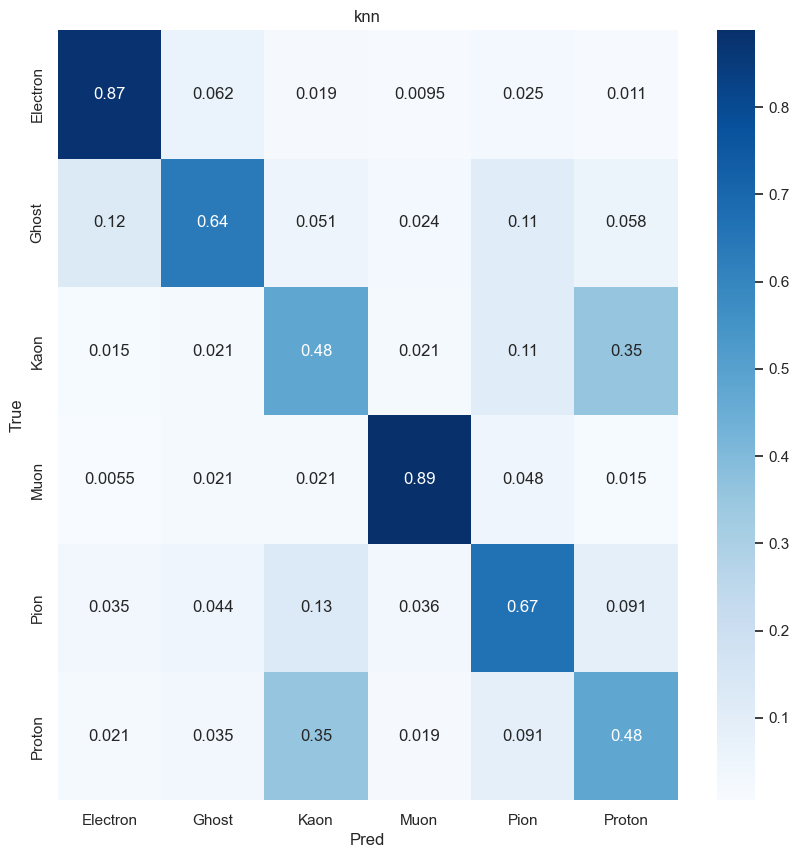

In [212]:
plot_cm(knn_model, X_test_knn, y_test, 'knn')

# Наивный байесовский классификатор

In [104]:
from sklearn.naive_bayes import GaussianNB

In [105]:
X_train_nb = X_train_log.copy()
X_test_nb = X_test_log.copy()

In [106]:
nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [107]:
y_pred = nb_model.predict(X_test_log)
nb_f1 = f1_score(y_test, y_pred, average='macro')

print(nb_f1)

0.6056854429879556


In [108]:
PATH_nb = "models_main/nb.joblib"
if not os.path.exists(PATH_nb):
    joblib.dump(nb_model, PATH_nb)

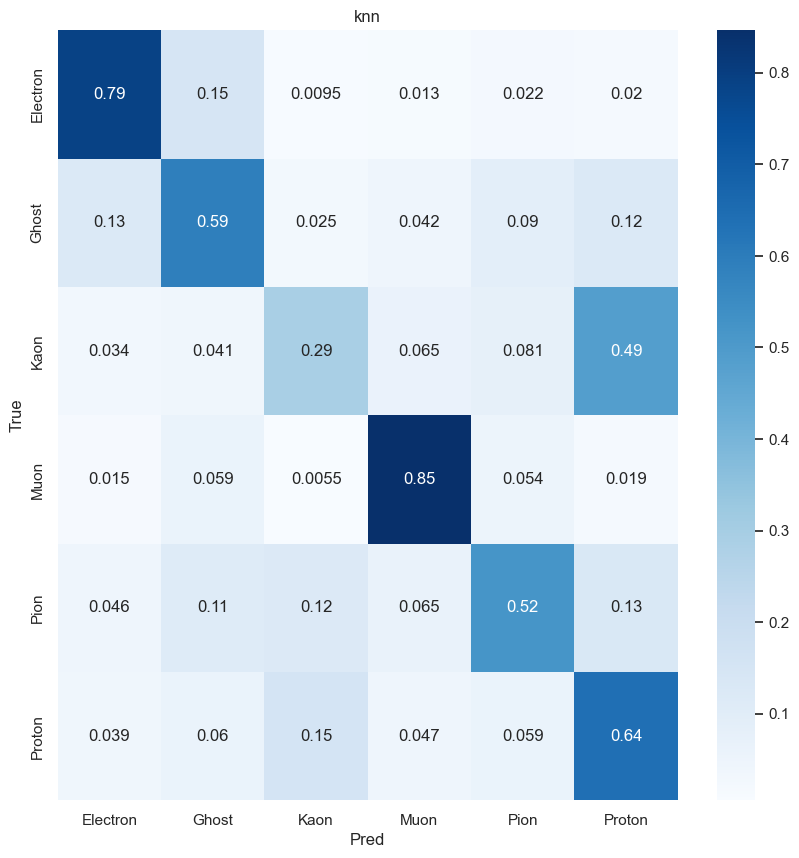

In [ ]:
plot_cm(nb_model, X_test_nb, y_test, 'knn')

# Деревья решений

In [109]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [110]:
X_train_tree = X_train_log.copy()
X_test_tree = X_test_log.copy()

In [111]:
def tree_params(trial):
    return {
        'max_depth': trial.suggest_int("max_depth", 2, 12),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 20),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 10),
        'max_features': trial.suggest_int("max_features", 1, X_train.shape[1]),
    }

In [112]:
tree_model = train_model(DecisionTreeClassifier, tree_params, X_train=X_train_tree, y_train=y_train)

[I 2026-05-30 07:10:42,674] A new study created in memory with name: no-name-4e8eb8f8-d86c-43c0-959b-4f3fa677329a
[I 2026-05-30 07:10:47,352] Trial 0 finished with value: 0.9187814622395833 and parameters: {'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 8, 'max_features': 36}. Best is trial 0 with value: 0.9187814622395833.
[I 2026-05-30 07:10:54,097] Trial 1 finished with value: 0.9110349934895833 and parameters: {'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 51}. Best is trial 0 with value: 0.9187814622395833.
[I 2026-05-30 07:10:58,792] Trial 2 finished with value: 0.9038005729166667 and parameters: {'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 49}. Best is trial 0 with value: 0.9187814622395833.
[I 2026-05-30 07:11:02,004] Trial 3 finished with value: 0.85563147265625 and parameters: {'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 48}. Best is trial 0 with value: 0.

In [113]:
y_pred = tree_model.predict(X_test_tree)
tree_f1 = f1_score(y_test, y_pred, average='macro')

print(tree_f1)

0.6152972341558072


In [114]:
PATH_tree = "models_main/tree.joblib"
if not os.path.exists(PATH_tree):
    joblib.dump(tree_model, PATH_tree)

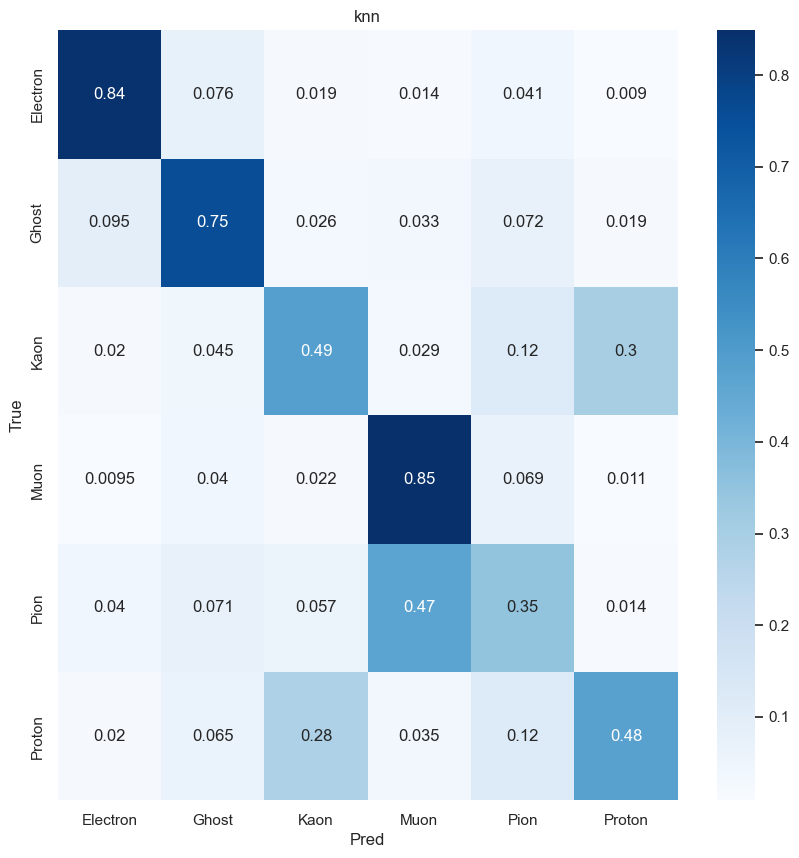

In [ ]:
plot_cm(tree_model, X_test_tree, y_test, 'tree')

In [115]:
tree_model_base = train_model(DecisionTreeClassifier, tree_params, X_train=X_train, y_train=y_train)

[I 2026-05-30 07:11:23,218] A new study created in memory with name: no-name-3d2b13b6-074f-46ca-9c58-624cd884a48d
[I 2026-05-30 07:11:26,890] Trial 0 finished with value: 0.89798337890625 and parameters: {'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 34}. Best is trial 0 with value: 0.89798337890625.
[I 2026-05-30 07:11:30,270] Trial 1 finished with value: 0.9154041341145833 and parameters: {'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 23}. Best is trial 1 with value: 0.9154041341145833.
[I 2026-05-30 07:11:31,695] Trial 2 finished with value: 0.8874264374999999 and parameters: {'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 8}. Best is trial 1 with value: 0.9154041341145833.
[I 2026-05-30 07:11:34,420] Trial 3 finished with value: 0.9049483854166667 and parameters: {'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 21}. Best is trial 1 with value: 0.9154

In [118]:
y_pred = tree_model_base.predict(X_test)
tree_f1_base = f1_score(y_test, y_pred, average='macro')

print(tree_f1_base)

0.6967292018643073


In [119]:
PATH_tree_base = "models_main/tree_base.joblib"
if not os.path.exists(PATH_tree_base):
    joblib.dump(tree_model_base, PATH_tree_base)

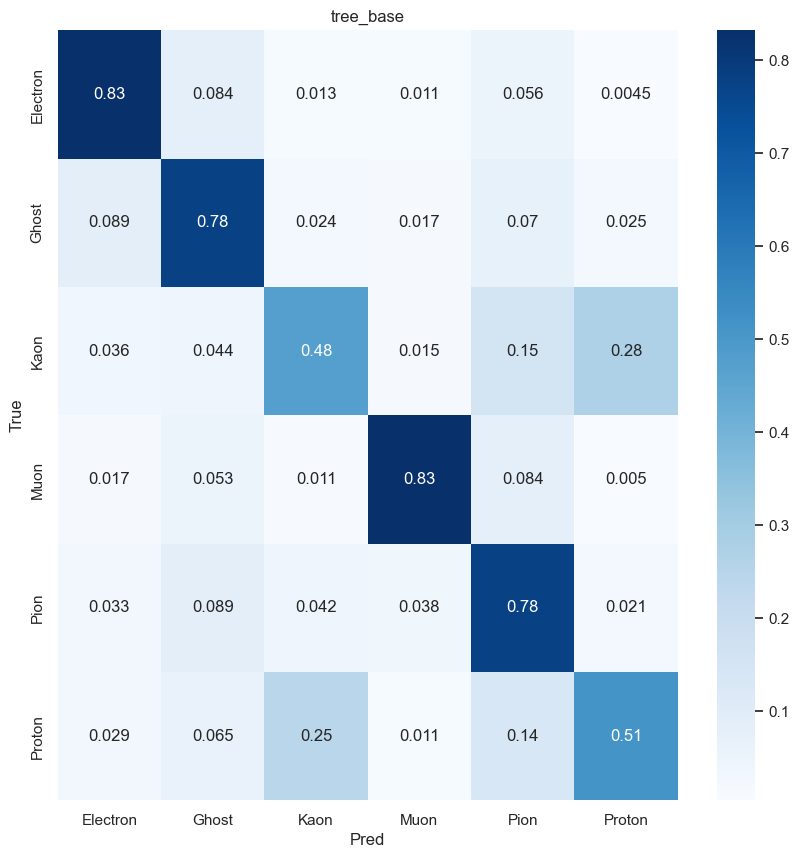

In [216]:
plot_cm(tree_model_base, X_test, y_test, 'tree_base')

In [122]:
def forest_params(trial):
    return {
        'n_estimators': trial.suggest_int("n_estimators", 30, 80),
        'max_depth': trial.suggest_int("max_depth", 2, 12),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 20),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 10),
        'max_features': trial.suggest_int("max_features", 1, X_train.shape[1]),
        'n_jobs': -1
    }

In [123]:
forest_model = train_model(RandomForestClassifier, forest_params, X_train=X_train_tree, y_train=y_train)

[I 2026-05-30 07:16:16,952] A new study created in memory with name: no-name-218a3362-05de-45d3-937a-6ed73e98aa0f
[I 2026-05-30 07:16:19,419] Trial 0 finished with value: 0.9211673020833333 and parameters: {'n_estimators': 36, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 3}. Best is trial 0 with value: 0.9211673020833333.
[I 2026-05-30 07:16:48,729] Trial 1 finished with value: 0.9384656627604165 and parameters: {'n_estimators': 62, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 37}. Best is trial 1 with value: 0.9384656627604165.
[I 2026-05-30 07:17:11,000] Trial 2 finished with value: 0.9438727057291665 and parameters: {'n_estimators': 79, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 18}. Best is trial 2 with value: 0.9438727057291665.
[I 2026-05-30 07:17:15,349] Trial 3 finished with value: 0.9243397916666666 and parameters: {'n_estimators': 68, 'max_depth': 7, 'min_samples_split': 2

In [124]:
y_pred = forest_model.predict(X_test_tree)
forest_f1 = f1_score(y_test, y_pred, average='macro')

print(forest_f1)

0.7314797222126624


In [125]:
PATH_forest = "models_main/forest.joblib"
if not os.path.exists(PATH_forest):
    joblib.dump(forest_model, PATH_forest)

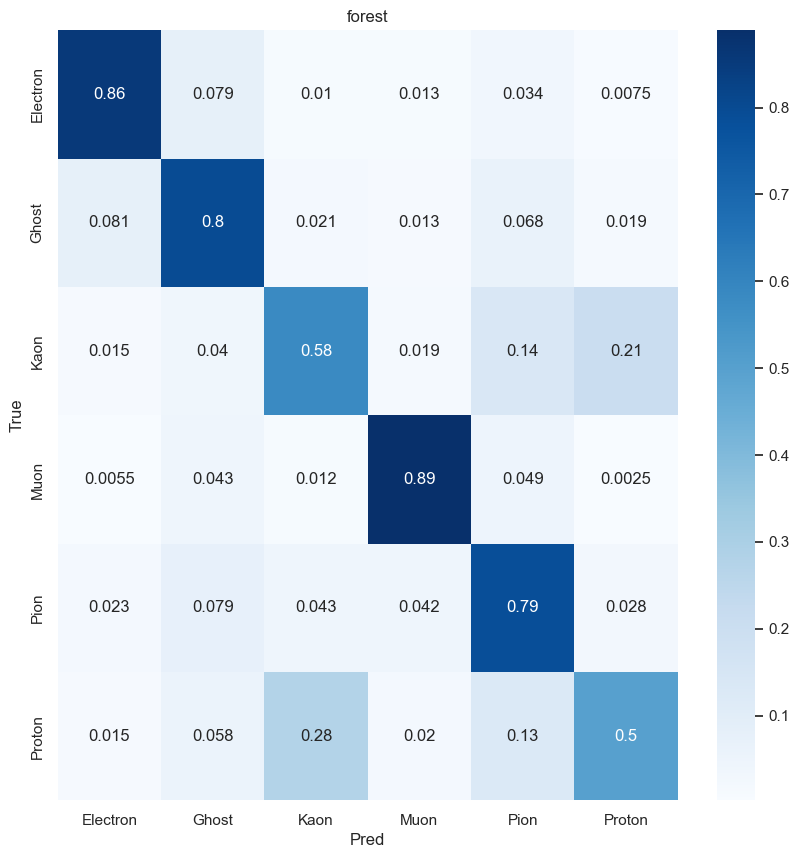

In [217]:
plot_cm(forest_model, X_test_tree, y_test, 'forest')

In [159]:
forest_model_base = train_model(RandomForestClassifier, forest_params, X_train=X_train, y_train=y_train)

[I 2026-05-30 10:28:53,892] A new study created in memory with name: no-name-6d429964-a328-4439-8ec9-542edf27aec1
[I 2026-05-30 10:29:31,383] Trial 0 finished with value: 0.9318530716145835 and parameters: {'n_estimators': 78, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 31}. Best is trial 0 with value: 0.9318530716145835.
[I 2026-05-30 10:30:03,831] Trial 1 finished with value: 0.94781611328125 and parameters: {'n_estimators': 77, 'max_depth': 12, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 17}. Best is trial 1 with value: 0.94781611328125.
[I 2026-05-30 10:30:31,073] Trial 2 finished with value: 0.9467528450520832 and parameters: {'n_estimators': 47, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 24}. Best is trial 1 with value: 0.94781611328125.
[I 2026-05-30 10:30:49,157] Trial 3 finished with value: 0.7585029296875 and parameters: {'n_estimators': 61, 'max_depth': 2, 'min_samples_split': 13, 'mi

In [160]:
y_pred = forest_model_base.predict(X_test)
forest_f1_base = f1_score(y_test, y_pred, average='macro')

print(forest_f1_base)

0.7404065651417953


In [161]:
PATH_forest_base = "models_main/forest_base.joblib"
if not os.path.exists(PATH_forest_base):
    joblib.dump(forest_model_base, PATH_forest_base)

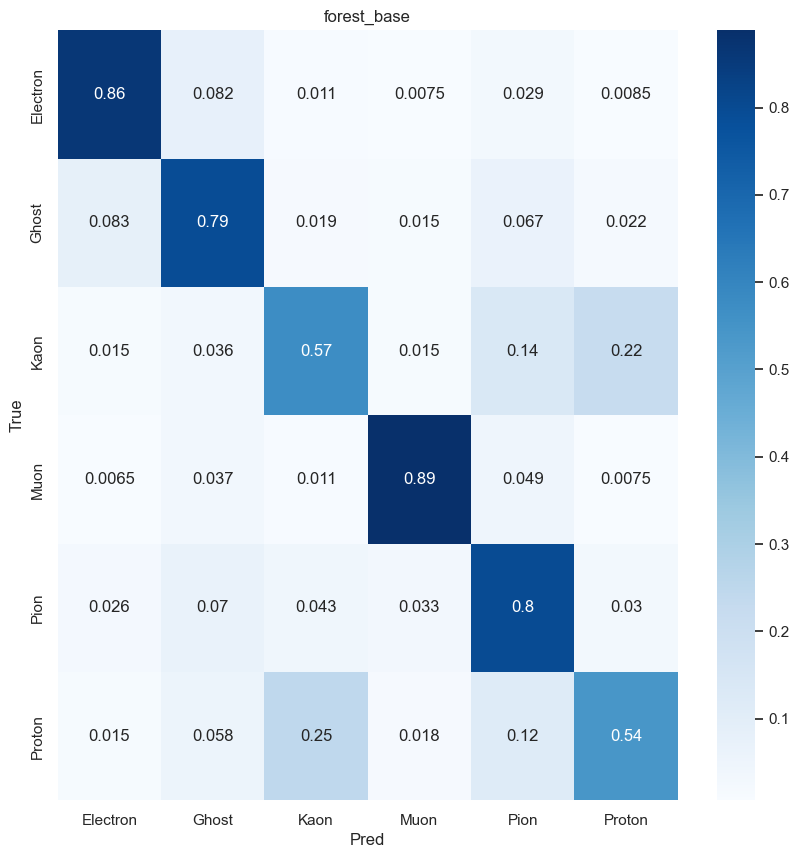

In [218]:
plot_cm(forest_model_base, X_test, y_test, 'forest_base')

# Градиентный бустинг

In [126]:
from xgboost import XGBClassifier

In [127]:
def xgb_params(trial):
    return {
        'max_depth': trial.suggest_int("max_depth", 2, 12),
        'n_estimators': trial.suggest_int("n_estimators", 100, 500),
        'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
    }

In [128]:
xgb_model = train_model(XGBClassifier, xgb_params, X_train=X_train_tree, y_train=y_train)

[I 2026-05-30 07:20:20,139] A new study created in memory with name: no-name-079a25d0-b953-424d-964b-1b977b297a14
[I 2026-05-30 07:21:01,280] Trial 0 finished with value: 0.9284926927083331 and parameters: {'max_depth': 2, 'n_estimators': 402, 'learning_rate': 0.0036145298708696403}. Best is trial 0 with value: 0.9284926927083331.
[I 2026-05-30 07:22:38,963] Trial 1 finished with value: 0.9487652760416667 and parameters: {'max_depth': 8, 'n_estimators': 219, 'learning_rate': 0.010428320474061267}. Best is trial 1 with value: 0.9487652760416667.
[I 2026-05-30 07:23:40,195] Trial 2 finished with value: 0.9402621848958332 and parameters: {'max_depth': 4, 'n_estimators': 436, 'learning_rate': 0.003525626798431556}. Best is trial 1 with value: 0.9487652760416667.
[I 2026-05-30 07:28:41,767] Trial 3 finished with value: 0.9474183255208333 and parameters: {'max_depth': 12, 'n_estimators': 241, 'learning_rate': 0.008956866170585871}. Best is trial 1 with value: 0.9487652760416667.
[I 2026-05-3

In [129]:
y_pred = xgb_model.predict(X_test_tree)
xgb_f1 = f1_score(y_test, y_pred, average='macro')

print(xgb_f1)

0.7285570077913958


In [130]:
PATH_xgb = "models_main/xgb.joblib"
if not os.path.exists(PATH_xgb):
    joblib.dump(xgb_model, PATH_xgb)

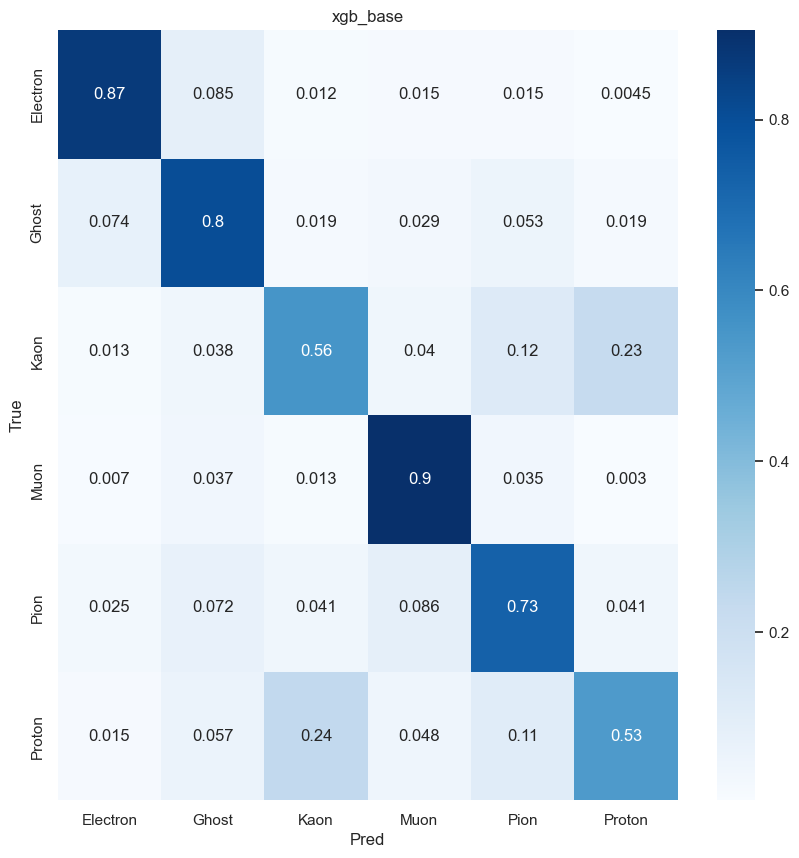

In [220]:
plot_cm(xgb_model, X_test_tree, y_test, 'xgb_base')

In [162]:
xgb_model_base = train_model(XGBClassifier, xgb_params, X_train=X_train, y_train=y_train)

[I 2026-05-30 10:34:37,078] A new study created in memory with name: no-name-ae5d443f-851f-462b-ab3a-7bb922c77e40
[I 2026-05-30 10:35:22,587] Trial 0 finished with value: 0.9396680026041666 and parameters: {'max_depth': 4, 'n_estimators': 310, 'learning_rate': 0.0049807815909486625}. Best is trial 0 with value: 0.9396680026041666.
[I 2026-05-30 10:37:24,610] Trial 1 finished with value: 0.9486791718750001 and parameters: {'max_depth': 10, 'n_estimators': 140, 'learning_rate': 0.016140535868003188}. Best is trial 1 with value: 0.9486791718750001.
[I 2026-05-30 10:37:39,619] Trial 2 finished with value: 0.9421098658854167 and parameters: {'max_depth': 4, 'n_estimators': 120, 'learning_rate': 0.017929850159764855}. Best is trial 1 with value: 0.9486791718750001.
[I 2026-05-30 10:40:02,024] Trial 3 finished with value: 0.9399456770833332 and parameters: {'max_depth': 9, 'n_estimators': 192, 'learning_rate': 0.0010801129400737663}. Best is trial 1 with value: 0.9486791718750001.
[I 2026-05-

In [163]:
y_pred = xgb_model_base.predict(X_test)
xgb_f1_base = f1_score(y_test, y_pred, average='macro')

print(xgb_f1_base)

0.7582898772201658


In [164]:
PATH_xgb_base = "models_main/xgb_base.joblib"
if not os.path.exists(PATH_xgb_base):
    joblib.dump(xgb_model_base, PATH_xgb_base)

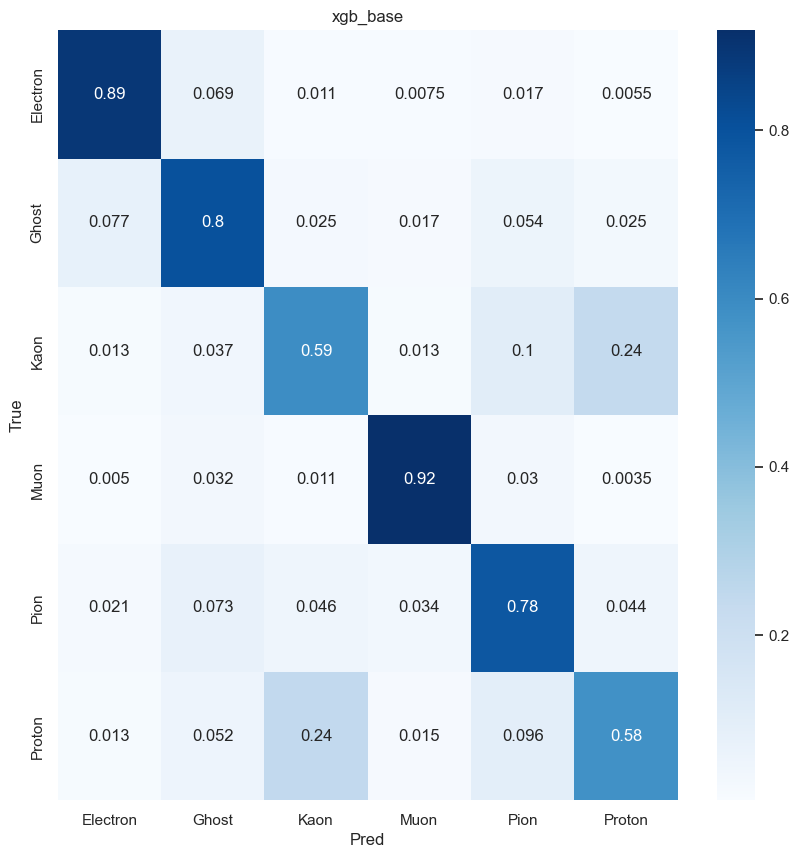

In [219]:
plot_cm(xgb_model_base, X_test, y_test, 'xgb_base')

# Метод опорных векторов

In [131]:
from sklearn.svm import SVC

In [135]:
def svm_params(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly'])
    params =  {
        'kernel': kernel,
        'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
        'probability': True
    }

    if kernel == 'rbf':
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    return params

In [139]:
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_log, y_train,
    train_size=5000,
    stratify=y_train,        
    random_state=SEED,
)

In [140]:
svm_model = train_model(SVC, svm_params, X_train=X_train_svm, y_train=y_train_svm, n_trials=5, cv_folds=2)

[I 2026-05-30 10:18:38,635] A new study created in memory with name: no-name-b46fbff3-e80b-45c7-8672-e108f7d69c4d
[I 2026-05-30 10:18:46,902] Trial 0 finished with value: 0.8949604387563115 and parameters: {'kernel': 'rbf', 'C': 0.0370247545778454, 'gamma': 'scale'}. Best is trial 0 with value: 0.8949604387563115.
[I 2026-05-30 10:18:54,266] Trial 1 finished with value: 0.9365659610409122 and parameters: {'kernel': 'linear', 'C': 1.6965641769477737}. Best is trial 1 with value: 0.9365659610409122.
[I 2026-05-30 10:18:57,564] Trial 2 finished with value: 0.9110379948809615 and parameters: {'kernel': 'poly', 'C': 7.805256873619484}. Best is trial 1 with value: 0.9365659610409122.
[I 2026-05-30 10:19:01,839] Trial 3 finished with value: 0.9306598652294005 and parameters: {'kernel': 'rbf', 'C': 2.175998008026248, 'gamma': 'scale'}. Best is trial 1 with value: 0.9365659610409122.
[I 2026-05-30 10:19:06,434] Trial 4 finished with value: 0.9220230903355967 and parameters: {'kernel': 'rbf', 'C

In [141]:
y_pred = svm_model.predict(X_test_log)
svm_f1 = f1_score(y_test, y_pred, average='macro')

print(svm_f1)

0.7270090819623246


In [142]:
PATH_svm = "models_main/svm.joblib"
if not os.path.exists(PATH_svm):
    joblib.dump(svm_model, PATH_svm)

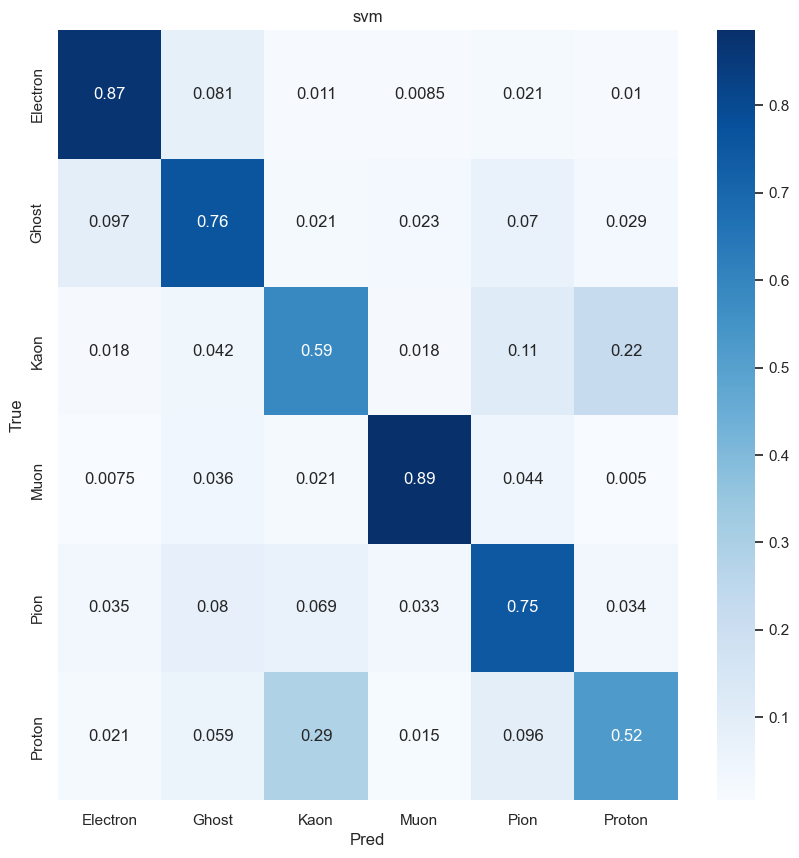

In [223]:
plot_cm(svm_model, X_test_log, y_test, 'svm')

# Полносвязная нейронная сеть (multi layer perceptron)

In [143]:
import keras

In [145]:
X_train_log.shape[1]

73

In [146]:
inputs = x = keras.layers.Input((X_train_log.shape[1], ), name='Input')

x = keras.layers.Dense(64, activation='relu', name='Dense1')(x)
x = keras.layers.Dropout(0.2, name='drop1')(x)
x = keras.layers.Dense(128, activation='relu', name='Dense2')(x)
x = keras.layers.Dropout(0.2, name='drop2')(x)
x = keras.layers.Dense(16, activation='relu', name='Dense3')(x)
x = keras.layers.Dense(len(np.unique(y_train)), activation='softmax', name='Output')(x)

model = keras.models.Model(inputs=inputs, outputs=x)

In [147]:
model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

In [148]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 73)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 64)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense3 (Dense)                  │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,222 (59.46 KB)

 Trainable params: 15,222 (59.46 KB)

 Non-trainable params: 0 (0.00 B)

In [149]:
model.fit(
    X_train_log, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6006 - loss: 0.9885 - val_accuracy: 0.6994 - val_loss: 0.7279
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6846 - loss: 0.7737 - val_accuracy: 0.7240 - val_loss: 0.6781
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7021 - loss: 0.7345 - val_accuracy: 0.7336 - val_loss: 0.6590
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7116 - loss: 0.7124 - val_accuracy: 0.7346 - val_loss: 0.6480
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7200 - loss: 0.6971 - val_accuracy: 0.7381 - val_loss: 0.6481
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7246 - loss: 0.6839 - val_accuracy: 0.7426 - val_loss: 0.6295
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7290 - loss: 0.6749 - val_accuracy: 0.7417 - val_loss: 0.6275
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7278 - loss: 0.6707 - val_accuracy: 0.

In [150]:
y_pred = model.predict(X_test_log).argmax(axis=1)
nn_f1 = f1_score(y_test, y_pred, average='macro')

print(nn_f1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
0.7518576142375796


In [151]:
PATH_nn = "models_main/nn.keras"
if not os.path.exists(PATH_nn):
    model.save(PATH_nn)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


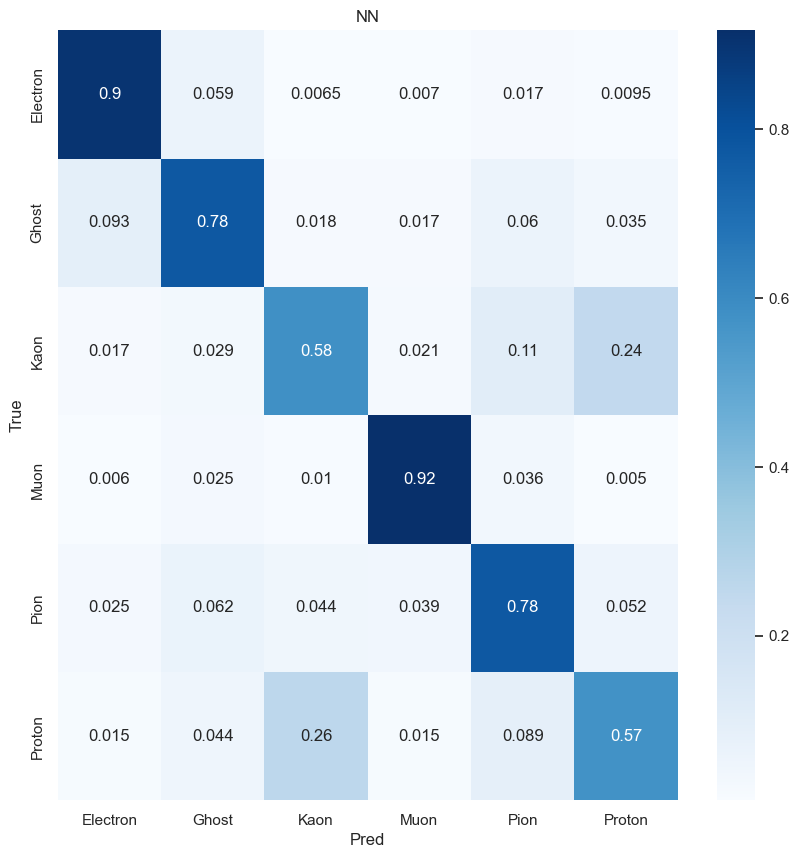

In [226]:
plot_cm(model, X_test_log, y_test, 'NN', keras=True)

# Ансамбль моделей

In [152]:
from sklearn.ensemble import VotingClassifier

In [153]:
ensemble_models = VotingClassifier(
    estimators=[
        ('nb', nb_model),
        ('knn', knn_model),
        ('rf', forest_model),
        ('xgb', xgb_model),
        ('log', logistic_model)
    ],
    n_jobs=-1,
    voting='soft'
)

In [154]:
ensemble_models.fit(X_train_log, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('nb', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'


In [155]:
y_pred = ensemble_models.predict(X_test_log)
ensemble_f1 = f1_score(y_test, y_pred, average='macro')

print(xgb_f1)

0.7285570077913958


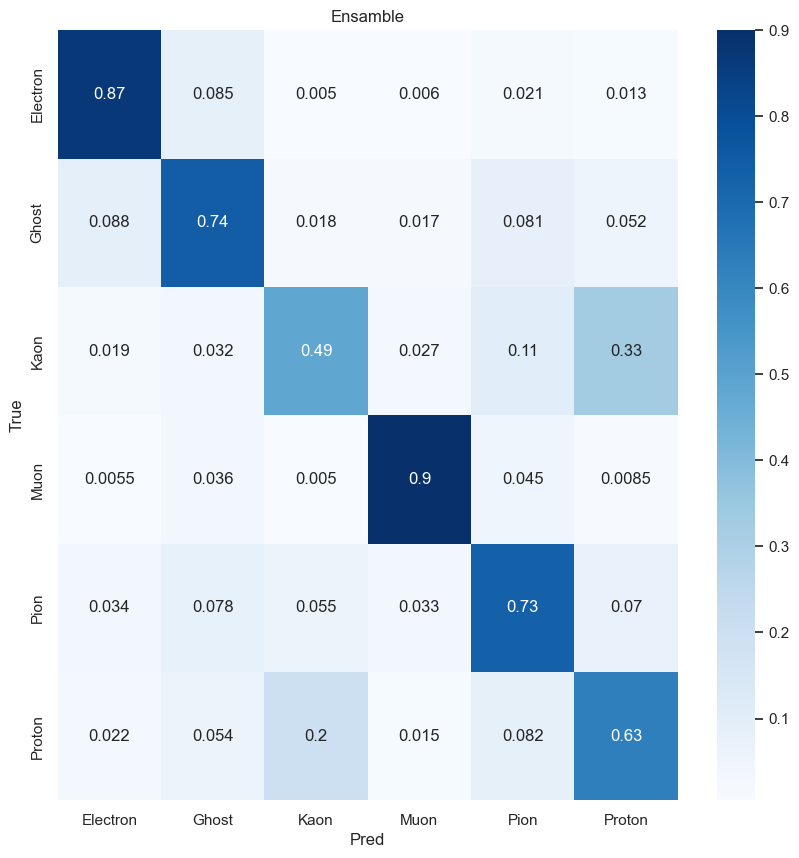

In [227]:
plot_cm(ensemble_models, X_test_log, y_test, 'Ensamble')

# Метрики

In [165]:
f1_metrics = {
    'OneRule': onerule_f1,
    'logistic Regression': logistic_f1,
    'logistic Regression with nan features': logistic_f1_nan,
    'KNN': knn_f1,
    'Gaussian Naive Bayes': nb_f1,
    'Tree': tree_f1,
    'Tree on base features': tree_f1_base,
    'Random Forest': forest_f1,
    'Random Forest on base features': forest_f1_base,
    'XGBoost': xgb_f1,
    'XGBoost on base features':xgb_f1_base,
    'SVM': svm_f1,
    'MLP': nn_f1,
    'Soft Voting Ensamble': ensemble_f1
}

In [166]:
f1_metrics

{'OneRule': 0.2935399961030701,
 'logistic Regression': 0.7322799725125999,
 'logistic Regression with nan features': 0.7363210641512884,
 'KNN': 0.6714672868121694,
 'Gaussian Naive Bayes': 0.6056854429879556,
 'Tree': 0.6152972341558072,
 'Tree on base features': 0.6967292018643073,
 'Random Forest': 0.7314797222126624,
 'Random Forest on base features': 0.7404065651417953,
 'XGBoost': 0.7285570077913958,
 'XGBoost on base features': 0.7582898772201658,
 'SVM': 0.7270090819623246,
 'MLP': 0.7518576142375796,
 'Soft Voting Ensamble': 0.7243164522665348}

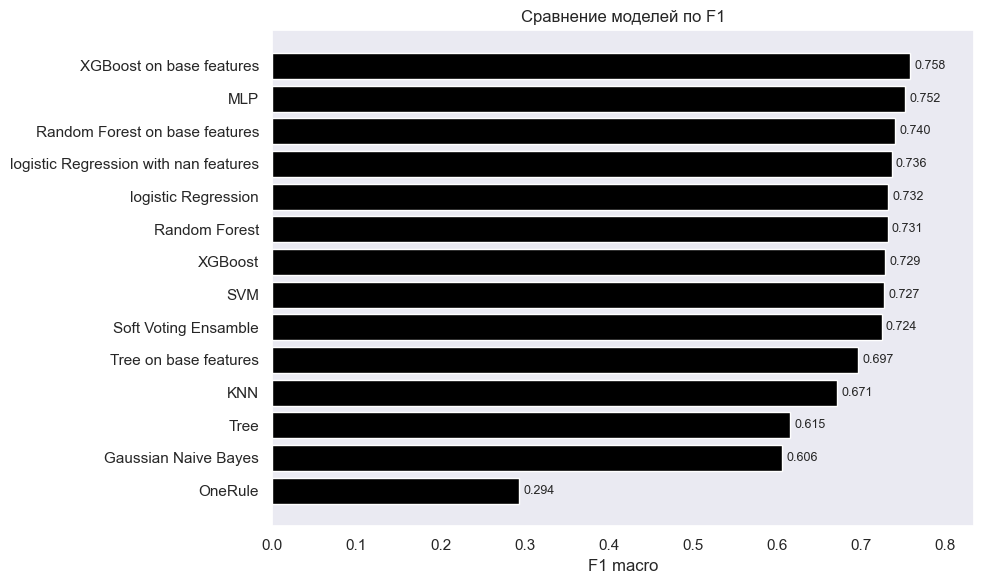

In [173]:
fig, ax = plt.subplots(figsize=(10, 6))

sorted_items = sorted(f1_metrics.items(), key=lambda x: x[1])
names, values = zip(*sorted_items)

bars = ax.barh(names, values, color='black')

for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('F1 macro')
ax.set_title('Сравнение моделей по F1')
ax.set_xlim(0, max(values) * 1.1)
plt.tight_layout()
plt.show()

# Важность признаков

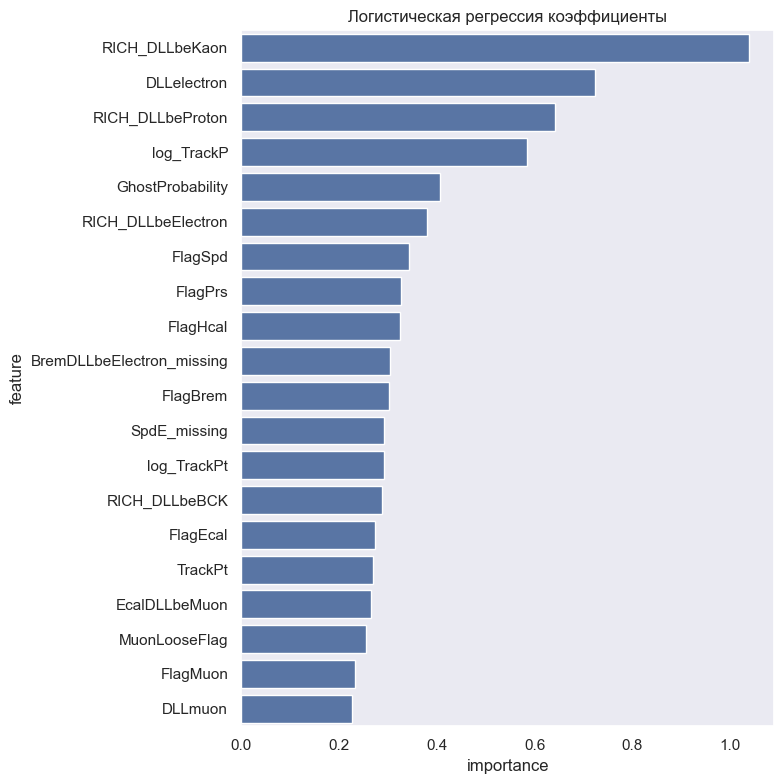

In [176]:
feature_names = X_train.columns.tolist() + [f'{c}_missing' for c in cols_nan]

importances = np.abs(logistic_model_nan.coef_).mean(axis=0)

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=imp_df.head(20), y='feature', x='importance', ax=ax)
ax.set_title('Логистическая регрессия коэффициенты')
plt.tight_layout()
plt.show()

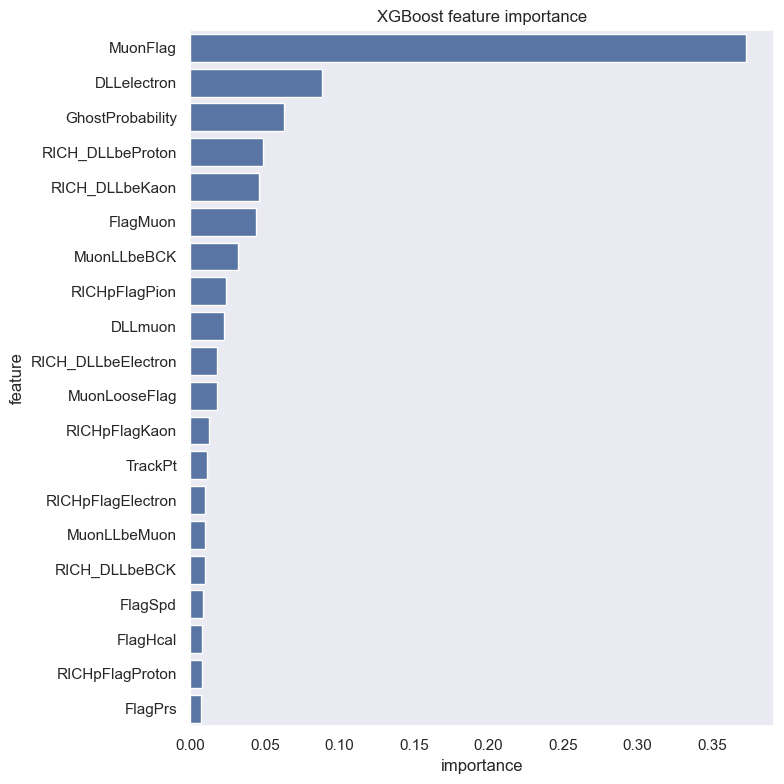

In [179]:
xgb_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model_base.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=xgb_imp.head(20), y='feature', x='importance', ax=ax)
ax.set_title('XGBoost feature importance')
plt.tight_layout()
plt.show()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

feature_names = X_train.columns.tolist()

n_features = X_train.shape[1]

base_model = LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    num_leaves=31,
    n_jobs=-1, 
    verbose=-1, 
    random_state=SEED,
)

selected = []
remaining = list(range(n_features))
history = []

max_features = 15

for step in range(max_features):
    best_score = -np.inf
    best_idx = None

    for idx in remaining:
        trial_features = selected + [idx]
        X_trial = X_train.iloc[:, trial_features]

        score = cross_val_score(
            base_model, 
            X_trial, 
            y_train, 
            cv=3, 
            scoring='f1_macro', 
            n_jobs=1
        ).mean()

        if score > best_score:
            best_score = score
            best_idx = idx

    selected.append(best_idx)
    remaining.remove(best_idx)
    history.append((feature_names[best_idx], best_score))

    print(f'Step {step+1}: + {feature_names[best_idx]}  f1={best_score}')

selected_names = [feature_names[i] for i in selected]

Step 1: + RICH_DLLbeElectron  f1=0.34949171181214417
Step 2: + RICH_DLLbeKaon  f1=0.4978977201800417
Step 3: + DLLmuon  f1=0.5735911293791981
Step 4: + GhostProbability  f1=0.6428991687275735
Step 5: + RICH_DLLbeProton  f1=0.6724605362488266
Step 6: + DLLelectron  f1=0.6958982838381989
Step 7: + MuonFlag  f1=0.7091204149170007
Step 8: + TrackP  f1=0.7142124147885204
Step 9: + TrackPt  f1=0.7182721994276428
Step 10: + TotalcalE  f1=0.7208301744562627
Step 11: + PrsE  f1=0.7222752172756931
Step 12: + MuonLooseFlag  f1=0.7252277481050359
Step 13: + FlagPrs  f1=0.7266086795322414
Step 14: + MuonLLbeMuon  f1=0.727699602701004
Step 15: + FlagEcal  f1=0.7299245904497272
